# This Notebook is used to create a visual representation of the Keypoints found in each image in the pose graph.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
import cv2
from PIL import Image
import os

### Read in Keypoints

In [38]:

folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/keypoint_results'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count}")

kp_points = []

for i in range(0,file_count,1):
    x=[]
    y=[]
    z=[]
    filename = filename=folder_path+f"/keypoint_{i:04d}.txt"
    with open(filename, 'r') as file:
        for line in file:
            if not line.strip():
                continue
            else:
                row = [float(val) for val in line.strip().split(",")]
                # if row[0] < 50.0 and row[1] < 50.0 and row[2] < 20.0:
                x.append(row[0])
                y.append(row[1])
                z.append(row[2])
    temp = np.array([x, y, z])
    kp_points.append(temp)
print("number of points in 1: ", len(kp_points[0][0]))
print("size: ",kp_points[0].shape)
print("point 0: ",kp_points[0][:,0])


Number of files: 53
number of points in 1:  707
size:  (3, 707)
point 0:  [288.191   34.4276   0.    ]


### Read in Images

Number of files: 53
Loaded 53 images.


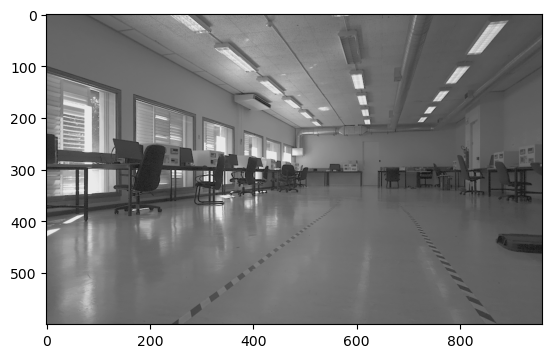

In [39]:

folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/images'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count}")

images = []

for j in range(0,file_count,1):
    x=[]
    y=[]
    z=[]
    filename = filename=folder_path+f"/image_{j:04d}.png"
    with open(filename, 'r') as file:
        img = cv2.imread(filename)
        if img is not None:
            images.append(img)
print(f"Loaded {len(images)} images.")
plt.imshow(images[0])


### Draw Keypoints on image

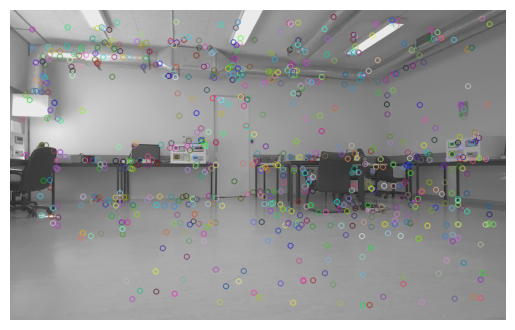

In [44]:
keypoints = []
vertex_num = 20
for j in range(points[vertex_num].shape[1]):
# for j in range(10):
    temp = cv2.KeyPoint(x=float(kp_points[vertex_num][0,j]), y=float(kp_points[vertex_num][1,j]), size=10.0 )
    keypoints.append(temp)

img_with_kp = cv2.drawKeypoints(images[vertex_num], keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Convert BGR → RGB for matplotlib
img_rgb = cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()